# Exploration et mini-classification ELAsTiCC2

- author : Sylvie Dagoret-Campagne
- affiliation : IJCLab/IN2P3/CNRS
- creation date : 2025-11-06 at NERSC (**kernel desc-td-env-dev**)
- last update : 2025-11-10 laptop on (**kernel pytorch-cpu-py312**)
- last update : 2025-12-31 at CCIN2P3 (**kernel desc_2026_py312**)

In [1]:
# ============================================================
# Notebook: Exploration et mini-classification ELAsTiCC2
# Kernel: desc-td-env-dev
# ============================================================

# -----------------------------
# 1️⃣ Imports
# -----------------------------

In [1]:
import sys
print(sys.executable)

/pbs/throng/lsst/users/dagoret/condaenvspkgs/desc_2026_py312/bin/python


In [2]:
import os
import socket
import numpy as np
import pandas as pd
import fitsio
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import random
random.seed(42)
np.random.seed(42)


In [5]:
def is_on_nersc():
    # Vérifier le nom d'hôte
    hostname = socket.gethostname()
    nersc_hostnames = ["perlmutter", "cori", "nersc.gov"]
    host_check = any(nersc_host in hostname for nersc_host in nersc_hostnames)

    # Vérifier les variables d'environnement
    nersc_vars = ["NERSC_HOST", "SLURM_JOB_ID", "CRAY_SYSTEM_NAME"]
    env_check = any(var in os.environ for var in nersc_vars)

    return host_check or env_check

def is_on_ccin2p3():
    hostname = socket.gethostname()
    cc_hostnames = ["cc.in2p3.fr"]
    host_check = any(cc_host in hostname for cc_host in cc_hostnames)
    return host_check 
    

if is_on_nersc():
    print("Je suis sur un système NERSC.")
elif is_on_ccin2p3():
    print("Je suis sur un système CCIN2P3.")
else:
    print("Je suis sur mon laptop ou un autre système.")


Je suis sur un système CCIN2P3.


In [ ]:
# -----------------------------
# 2️⃣ Définir les chemins NERSC et CCIN2P3
# -----------------------------

In [6]:
if is_on_nersc():
    print("Configuration pour NERSC : utilisation des GPU ou des chemins spécifiques.")
    # Exemple : charger des données depuis un chemin NERSC
    BASE_PATH = "/global/cfs/cdirs/lsst/www/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"
elif is_on_ccin2p3():
    BASE_PATH = "/sps/lsst/groups/desc/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"
else:
    print("Configuration pour laptop : utilisation des ressources locales.")
    # Exemple : charger des données depuis un chemin local
    BASE_PATH = "/Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"


In [7]:
# Liste des types de SN (sous-dossiers)
types_sn = [d for d in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, d))]
print("Types disponibles :", types_sn[:10])

Types disponibles : ['ELASTICC2_TRAIN_02_CLAGN', 'ELASTICC2_TRAIN_02_SNIc-Templates', 'ELASTICC2_TRAIN_02_SNIb+HostXT_V19', 'ELASTICC2_TRAIN_02_d-Sct', 'ELASTICC2_TRAIN_02_SNIIb+HostXT_V19', 'ELASTICC2_TRAIN_02_PISN', 'ELASTICC2_TRAIN_02_SNII-Templates', 'ELASTICC2_TRAIN_02_RRL', 'ELASTICC2_TRAIN_02_EB', 'ELASTICC2_TRAIN_02_SNIIn-MOSFIT']


In [8]:
sample_types = [
    "ELASTICC2_TRAIN_02_SNIa-SALT3",
    "ELASTICC2_TRAIN_02_SNIc-Templates",
    "ELASTICC2_TRAIN_02_SNIb-Templates"
]

HEAD colonnes : ('SNID', 'IAUC', 'FAKE', 'RA', 'DEC', 'PIXSIZE', 'NXPIX', 'NYPIX', 'SNTYPE', 'NOBS', 'PTROBS_MIN', 'PTROBS_MAX', 'MWEBV', 'MWEBV_ERR', 'REDSHIFT_HELIO', 'REDSHIFT_HELIO_ERR', 'REDSHIFT_FINAL', 'REDSHIFT_FINAL_ERR', 'VPEC', 'VPEC_ERR', 'HOSTGAL_NMATCH', 'HOSTGAL_NMATCH2', 'HOSTGAL_OBJID', 'HOSTGAL_FLAG', 'HOSTGAL_PHOTOZ', 'HOSTGAL_PHOTOZ_ERR', 'HOSTGAL_SPECZ', 'HOSTGAL_SPECZ_ERR', 'HOSTGAL_RA', 'HOSTGAL_DEC', 'HOSTGAL_SNSEP', 'HOSTGAL_DDLR', 'HOSTGAL_CONFUSION', 'HOSTGAL_LOGMASS', 'HOSTGAL_LOGMASS_ERR', 'HOSTGAL_LOGSFR', 'HOSTGAL_LOGSFR_ERR', 'HOSTGAL_LOGsSFR', 'HOSTGAL_LOGsSFR_ERR', 'HOSTGAL_COLOR', 'HOSTGAL_COLOR_ERR', 'HOSTGAL_ELLIPTICITY', 'HOSTGAL_OBJID2', 'HOSTGAL_SQRADIUS', 'HOSTGAL_OBJID_UNIQUE', 'HOSTGAL_ZPHOT_Q000', 'HOSTGAL_ZPHOT_Q010', 'HOSTGAL_ZPHOT_Q020', 'HOSTGAL_ZPHOT_Q030', 'HOSTGAL_ZPHOT_Q040', 'HOSTGAL_ZPHOT_Q050', 'HOSTGAL_ZPHOT_Q060', 'HOSTGAL_ZPHOT_Q070', 'HOSTGAL_ZPHOT_Q080', 'HOSTGAL_ZPHOT_Q090', 'HOSTGAL_ZPHOT_Q100', 'HOSTGAL_MAG_u', 'HOSTGAL_MAG

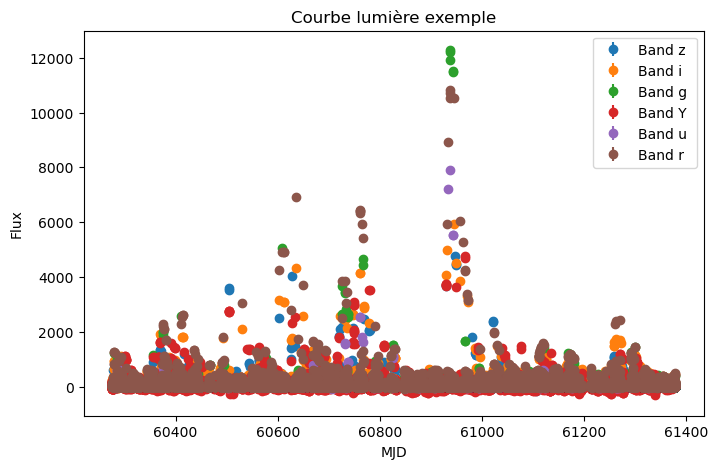

In [12]:
type_dir = os.path.join(BASE_PATH, "ELASTICC2_TRAIN_02_SNIa-SALT3")

# Lister HEAD et PHOT compressés
head_files = sorted([f for f in os.listdir(type_dir) if "HEAD" in f])
phot_files = sorted([f for f in os.listdir(type_dir) if "PHOT" in f])

# Choisir un objet pour test
head_file = head_files[0]
phot_file = phot_files[0]

head_data = fitsio.FITS(os.path.join(type_dir, head_file))[1].read()
phot_data = fitsio.FITS(os.path.join(type_dir, phot_file))[1].read()

print("HEAD colonnes :", head_data.dtype.names)
print("PHOT colonnes :", phot_data.dtype.names)

# Visualisation multibande
bands = set(phot_data["BAND"])
bands = {b for b in bands if b.strip() != '-'}
print(bands)

plt.figure(figsize=(8,5))
for b in bands:
    mask = phot_data["BAND"] == b
    plt.errorbar(phot_data["MJD"][mask], phot_data["FLUXCAL"][mask],
                 yerr=phot_data["FLUXCALERR"][mask], fmt='o', label=f'Band {b}')
plt.xlabel("MJD")
plt.ylabel("Flux")
plt.title("Courbe lumière exemple")
plt.legend()
plt.show()


✅ Ce que fait ce code :

- Parcourt plusieurs types de SN sélectionnés.
- Lit HEAD + PHOT compressés .FITS.gz.
- Filtre les bandes bidon '-' et supprime les espaces.
- Extrait pour chaque bande :
    - Flux maximum
    - MJD du pic
- Extrait quelques features globales depuis HEAD (nombre d’observations NOBS, redshift final).
- Retourne un DataFrame prêt pour un modèle ML et un vecteur de labels.

In [10]:
features_list = []
labels = []

for sn_type in sample_types:
    type_dir = os.path.join(BASE_PATH, sn_type)
    
    # Lister HEAD et PHOT
    head_files = sorted([f for f in os.listdir(type_dir) if "HEAD" in f])
    phot_files = sorted([f for f in os.listdir(type_dir) if "PHOT" in f])
    
    # Pour chaque objet, extraire features simples
    for head_file, phot_file in zip(head_files, phot_files):
        head_data = fitsio.FITS(os.path.join(type_dir, head_file))[1].read()
        phot_data = fitsio.FITS(os.path.join(type_dir, phot_file))[1].read()
        
        # Nettoyage des bandes
        bands = set(b.strip() for b in phot_data["BAND"] if b.strip() != '-')
        
        feature_dict = {}
        for b in bands:
            mask = np.array([x.strip() for x in phot_data["BAND"]]) == b
            if np.sum(mask) > 0:
                feature_dict[f"flux_max_{b}"] = np.max(phot_data["FLUXCAL"][mask])
                feature_dict[f"mjd_peak_{b}"] = phot_data["MJD"][mask][np.argmax(phot_data["FLUXCAL"][mask])]
            else:
                feature_dict[f"flux_max_{b}"] = 0
                feature_dict[f"mjd_peak_{b}"] = 0
        
        # Ajouter des features globales depuis HEAD si souhaité
        feature_dict["NOBS"] = head_data["NOBS"][0]
        feature_dict["REDSHIFT_FINAL"] = head_data["REDSHIFT_FINAL"][0]
        
        features_list.append(feature_dict)
        labels.append(sn_type)

# Convertir en DataFrame pour ML
X = pd.DataFrame(features_list)
y = np.array(labels)

print("Shape features :", X.shape)
print("Exemple features :\n", X.head())


Shape features : (120, 14)
Exemple features :
      flux_max_z  mjd_peak_z    flux_max_g  mjd_peak_g    flux_max_i  \
0   4751.000488  60948.0698  12285.958008  60938.0151   5940.501465   
1  10553.831055  60601.3404   5653.575195  61085.2029  12887.894531   
2  13273.971680  60370.2016  29886.800781  60372.1454  15945.262695   
3   3144.987305  61165.3956   5258.897461  60291.0970   4008.102295   
4   6253.601074  60920.3019  14648.594727  61121.2809   8097.628418   

   mjd_peak_i   flux_max_Y  mjd_peak_Y    flux_max_r  mjd_peak_r  \
0  60945.0880  4752.936523  60967.0332  10832.589844  60938.0399   
1  60601.3290  8060.200195  60599.2872  13974.723633  60612.3360   
2  60370.1779  9413.978516  60395.2067  32289.046875  60377.1782   
3  60523.4269  3581.779053  60540.3078   5547.472656  60527.3094   
4  60911.3270  5266.664551  60919.3044  12668.076172  61121.3049   

     flux_max_u  mjd_peak_u  NOBS  REDSHIFT_FINAL  
0   7888.285645  60937.1071    33        0.438268  
1   3543.0854

🔹 Ce que fait ce code

- Split train/test avec 70/30, stratifié par type de SN.
- Entraîne un RandomForest sur les features extraites (flux_max par bande, MJD du pic, NOBS, REDSHIFT_FINAL).
- Affiche un rapport de classification et une matrice de confusion.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Séparer train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Créer le modèle
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Prédictions
y_pred = clf.predict(X_test)

# Évaluation
print("Classification report :\n")
print(classification_report(y_test, y_pred))

print("Confusion matrix :\n")
print(confusion_matrix(y_test, y_pred))


Classification report :

                                   precision    recall  f1-score   support

    ELASTICC2_TRAIN_02_SNIa-SALT3       1.00      0.92      0.96        12
ELASTICC2_TRAIN_02_SNIb-Templates       0.62      0.83      0.71        12
ELASTICC2_TRAIN_02_SNIc-Templates       0.78      0.58      0.67        12

                         accuracy                           0.78        36
                        macro avg       0.80      0.78      0.78        36
                     weighted avg       0.80      0.78      0.78        36

Confusion matrix :

[[11  1  0]
 [ 0 10  2]
 [ 0  5  7]]


In [ ]:

# Inférence sur la totalité des data

if not is_on_nersc():
    assert False

# -----------------------------
# 2️⃣ Définir les chemins NERSC
# -----------------------------
ELASTIC2_PATH = "/global/cfs/cdirs/desc-td/ELASTICC2/"
HEAD_PATH = os.path.join(ELASTIC2_PATH, "HEAD")
PHOT_PATH = os.path.join(ELASTIC2_PATH, "PHOT")



# Vérifier qu'il y a des fichiers
head_files = os.listdir(HEAD_PATH)
phot_files = os.listdir(PHOT_PATH)
print(f"HEAD files: {head_files[:5]}")
print(f"PHOT files: {phot_files[:5]}")

# -----------------------------
# 3️⃣ Lire un HEAD aléatoire
# -----------------------------
head_file = os.path.join(HEAD_PATH, random.choice(head_files))
head_data = fitsio.FITS(head_file)[1].read()
print("Colonnes HEAD :", head_data.dtype.names)
print("Exemple HEAD :\n", head_data[:5])

# -----------------------------
# 4️⃣ Lire un PHOT correspondant
# -----------------------------
# On prend l'objet SNID du HEAD
snid = head_data["SNID"][0]
phot_file = os.path.join(PHOT_PATH, f"PHOT-{head_file.split('-')[1]}.FITS")
phot_data = fitsio.FITS(phot_file)[1].read()
# Filtrer pour le SNID choisi
phot_sn = phot_data[phot_data["SNID"] == snid]
print("Colonnes PHOT :", phot_data.dtype.names)
print("Exemple PHOT :\n", phot_sn[:5])

# -----------------------------
# 5️⃣ Visualiser la courbe multibande
# -----------------------------
bands = np.unique(phot_sn["BAND"])
plt.figure(figsize=(8,5))
for b in bands:
    mask = phot_sn["BAND"] == b
    plt.errorbar(phot_sn["MJD"][mask], phot_sn["FLUXCAL"][mask],
                 yerr=phot_sn["FLUXCALERR"][mask], fmt='o', label=f'Band {b}')
plt.xlabel("MJD")
plt.ylabel("Flux")
plt.title(f"Courbe lumière SNID {snid}")
plt.legend()
plt.show()

# -----------------------------
# 6️⃣ Construire un mini-dataset pour ML
# -----------------------------
# Feature simple : flux max par bande et MJD du pic
features_list = []
labels = []

for obj in head_data[:50]:  # petit sous-échantillon pour test
    snid = obj["SNID"]
    sn_type = obj["TYPE"]  # type de SN
    phot_obj = phot_data[phot_data["SNID"] == snid]
    feature_dict = {}
    for b in bands:
        mask = phot_obj["BAND"] == b
        if mask.sum() > 0:
            feature_dict[f"flux_max_{b}"] = np.max(phot_obj["FLUXCAL"][mask])
            feature_dict[f"mjd_peak_{b}"] = phot_obj["MJD"][mask][np.argmax(phot_obj["FLUXCAL"][mask])]
        else:
            feature_dict[f"flux_max_{b}"] = 0
            feature_dict[f"mjd_peak_{b}"] = 0
    features_list.append(feature_dict)
    labels.append(sn_type)

X = pd.DataFrame(features_list)
y = np.array(labels)
print("Features shape:", X.shape)
print("Labels:", np.unique(y))

# -----------------------------
# 7️⃣ Split train/test
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# -----------------------------
# 8️⃣ Entraîner un RandomForest simple
# -----------------------------
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# -----------------------------
# 9️⃣ Évaluer le modèle
# -----------------------------
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
